In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

data = pd.read_excel("local/НИР ежедневник.xlsx", sheet_name="Дни").fillna(value=-1)
data = data[data["Unnamed: 3"] != -1]

C:\Users\Professional\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Users\Professional\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [182]:
# this_year[this_year['work']]['record'].mean()
this_year[this_year['work'] & (this_year['plan'] == 'my-003')]['record'].mean()

np.float64(0.3423728813559322)

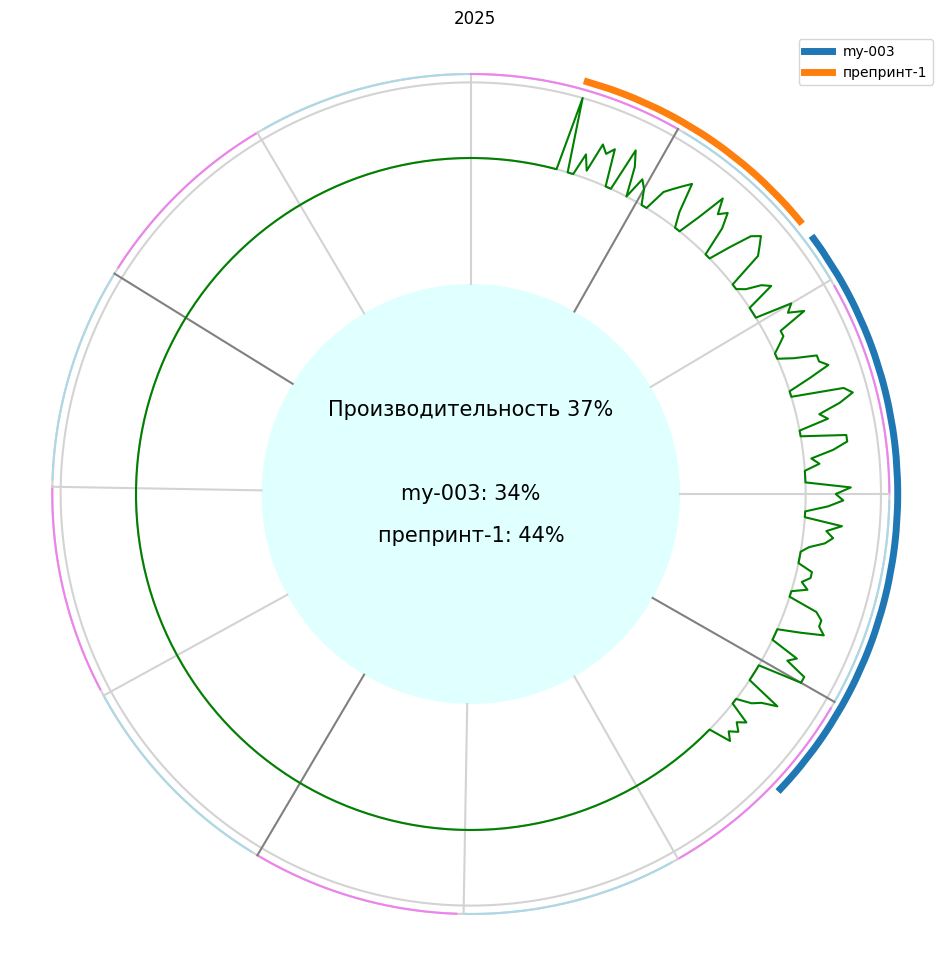

In [186]:
for year in range(data["Дата"][0].year, data["Дата"][len(data)-1].year + 1):
    mmdd = list(pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='d').strftime('%m-%d'))
    this_year = pd.DataFrame([[int(i) for i in j.split("-")] + [0.0, '', False] for j in mmdd], columns=['m', 'd', 'record', 'plan', 'work'])
    for i in range(len(data)):
        if data.iloc[i,0].year == year:
            m = data.iloc[i,0].month
            d = data.iloc[i,0].day
            r = data.iloc[i,2]
            p = data.iloc[i,5]
            j = this_year[(this_year["m"] == m) & (this_year["d"] == d)].index
            this_year.loc[j, 'record'] = r
            this_year.loc[j, 'plan'] = p
            this_year.loc[j, 'work'] = True

    fig, ax = plt.subplots(figsize=(12,12))
    
    record_failed = 0.8
    record_success = 0.98
    plan_pos = 1.02
    internal_circle = 0.5
    
    t = np.linspace(np.pi/2, 5*np.pi/2, len(this_year))
    def circ_plot(a, t, color=None, label=None, lw=None):
        plt.plot(a*np.cos(t), a*np.sin(t), color=color, label=label, lw=lw)
    # def fluctuation(bot, top, n):
    #     return [(-1)**i * (top-bot)/2 + bot + (top-bot)/2 for i in range(n)]
    
    # Отображение года и месяцев
    circ_plot(1, t, 'lightgray')
    circ_plot(record_failed, t, 'lightgray')
    circ_plot(record_success, t, 'lightgray')
    for m in range(1, 13):
        t_ = t[this_year[this_year['m']==m].index]
        circ_plot(1, t_, ['violet', 'lightblue'][m % 2])
        plt.plot([internal_circle*np.cos(t_[0]), np.cos(t_[0])], [internal_circle*np.sin(t_[0]), np.sin(t_[0])], ['lightgray', 'gray'][int(m % 3 == 0)])
    
    # Отображение продуктивности
    circ_plot(this_year['record'].to_numpy() * (record_success - record_failed) + record_failed, t, 'green')
    
    # Отображение продктивности
    plannes = list(this_year[this_year['plan']!='']['plan'].unique())
    for p in plannes:
       t_ = t[ this_year[this_year['plan']==p].index]
       circ_plot(plan_pos, t_, label=p, lw=5)

    # Краткая сводка
    circle = Circle((0, 0), radius=internal_circle, edgecolor=None, facecolor='lightcyan')
    ax.add_patch(circle)
    record_mean = this_year[this_year['work']]['record'].mean()
    plt.text(0, 0.2, f"Производительность {round(record_mean*100)}%", fontsize=15, ha='center', va='center')
    for i, p in enumerate(plannes):
        record_mean = this_year[this_year['work'] & (this_year['plan'] == p)]['record'].mean()
        plt.text(0, 0.1 - 0.1*(i+1), f"{p}: {round(record_mean*100)}%", fontsize=15, ha='center', va='center')
    
    plt.title(year)
    plt.legend()
    plt.axis('equal')
    plt.axis('off')
    plt.show()